In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [168]:
print("Hello")

Hello


In [169]:
import pandas as pd

In [170]:
df = pd.read_csv("customer_churn.csv")

In [171]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [172]:
df.shape

(7043, 21)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [174]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [175]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [176]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [177]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [178]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [179]:
df.dropna(inplace=True)

In [180]:
df.shape

(7032, 21)

In [181]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

- Dataset initially contained 7043 rows and 21 columns.
- TotalCharges had 11 blank values.
- Converted blank values to NaN.
- Removed missing rows.
- Final dataset contains 7032 rows.
- No duplicate records were found.

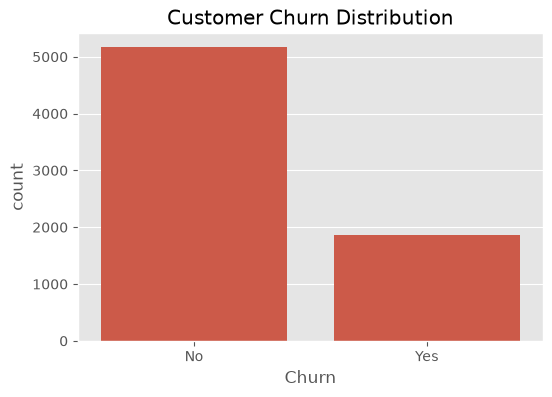

In [182]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

## Churn Distribution

- Most customers did not churn.
- The dataset is imbalanced because the "No" class has more samples than the "Yes" class.

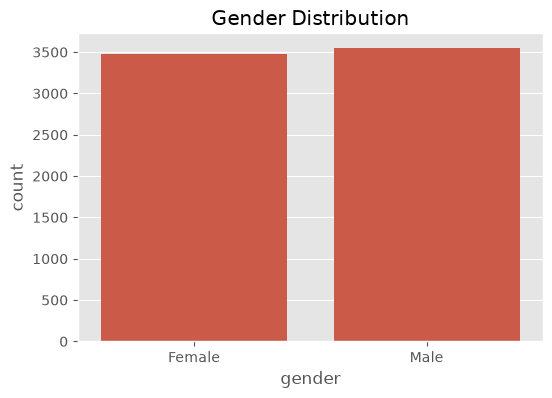

In [183]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", data=df)

plt.title("Gender Distribution")

plt.show()

## Gender Distribution

- Male and Female customers are almost equally represented.
- No major gender imbalance exists.

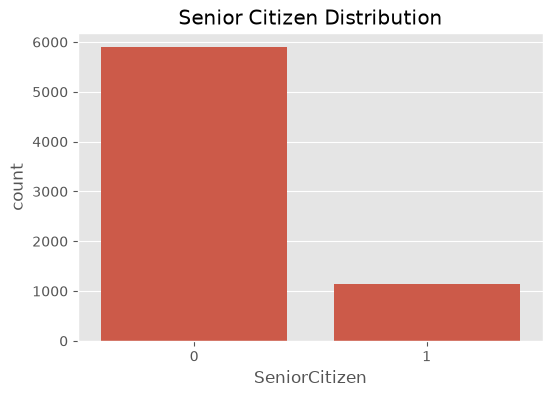

In [184]:
plt.figure(figsize=(6,4))

sns.countplot(x="SeniorCitizen", data=df)

plt.title("Senior Citizen Distribution")

plt.show()

## Senior Citizen

- Most customers are not senior citizens.
- Senior citizens form a smaller portion of the dataset.

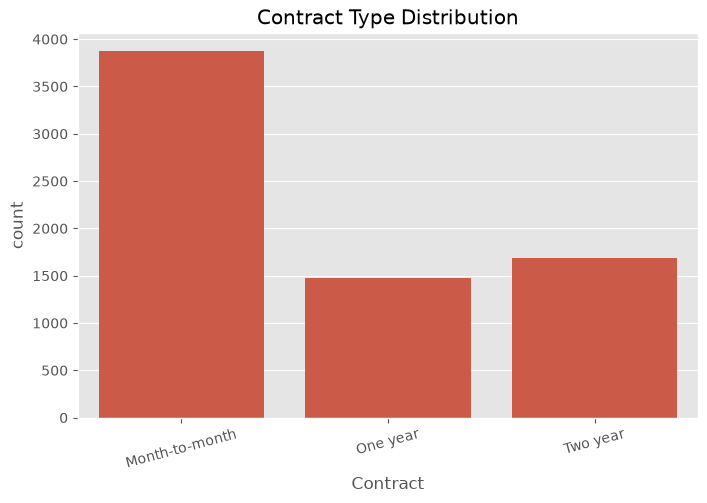

In [185]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", data=df)

plt.title("Contract Type Distribution")

plt.xticks(rotation=15)

plt.show()

## Contract Type

- Month-to-month contracts are the most common.
- Two-year contracts are the least common.

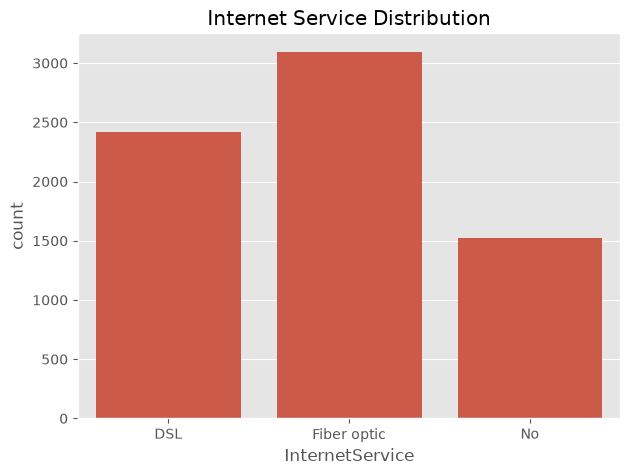

In [186]:
plt.figure(figsize=(7,5))

sns.countplot(x="InternetService", data=df)

plt.title("Internet Service Distribution")

plt.show()

## Internet Service

- Fiber optic and DSL are the dominant internet services.
- Some customers do not use internet service.

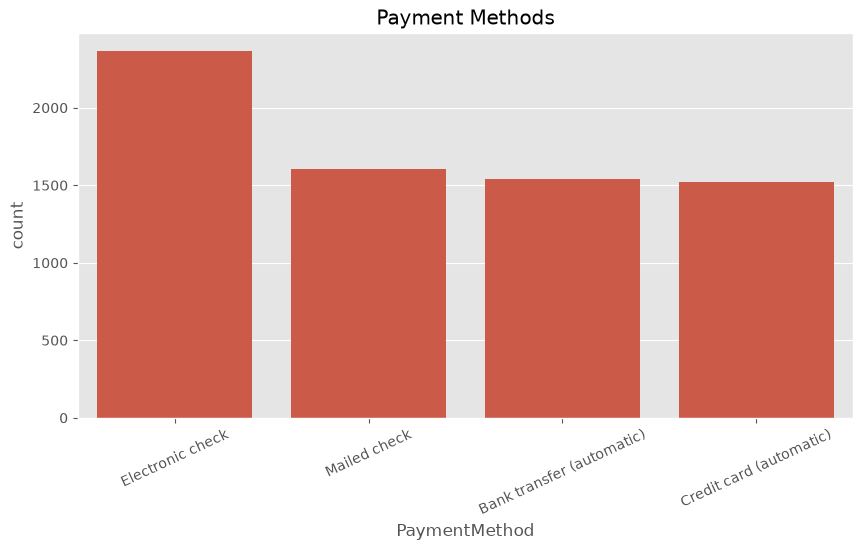

In [187]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", data=df)

plt.xticks(rotation=25)

plt.title("Payment Methods")

plt.show()

## Payment Method

- Electronic Check is commonly used.
- Other payment methods are also well represented.

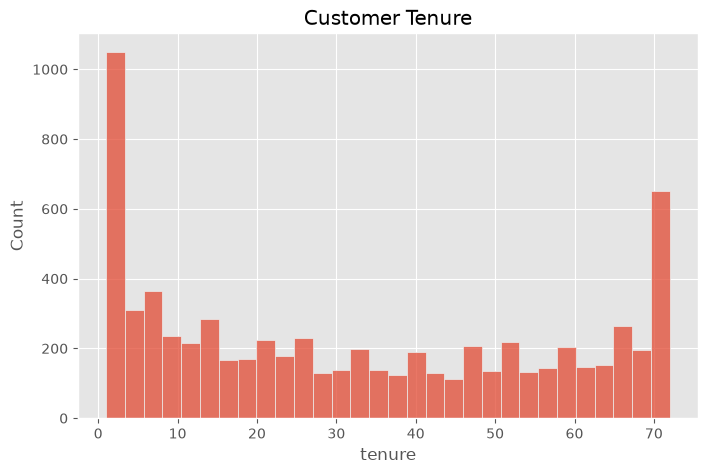

In [188]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30)

plt.title("Customer Tenure")

plt.show()

## Tenure

- Many customers have low tenure.
- Long-term customers are fewer.

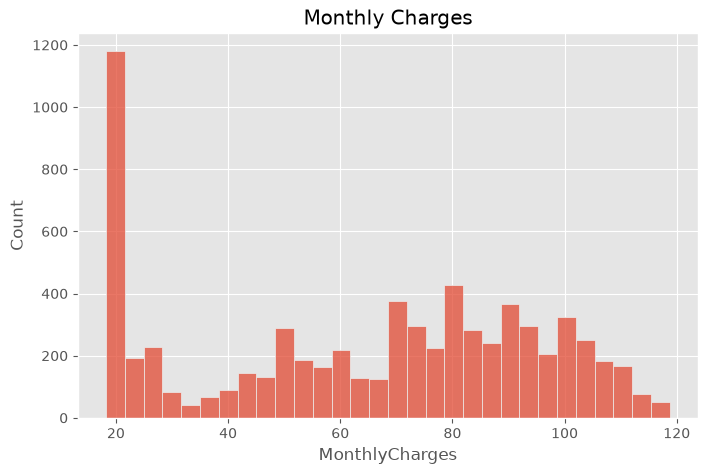

In [189]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges")

plt.show()

## Monthly Charges

- Monthly charges vary across customers.
- Most values fall in the lower to middle price range.

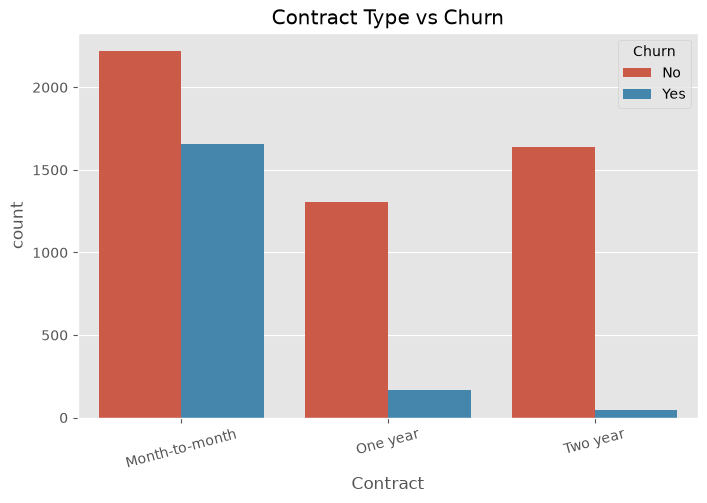

In [190]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

## Contract vs Churn

- Customers with month-to-month contracts churn the most.
- Customers with longer contracts are more likely to stay.

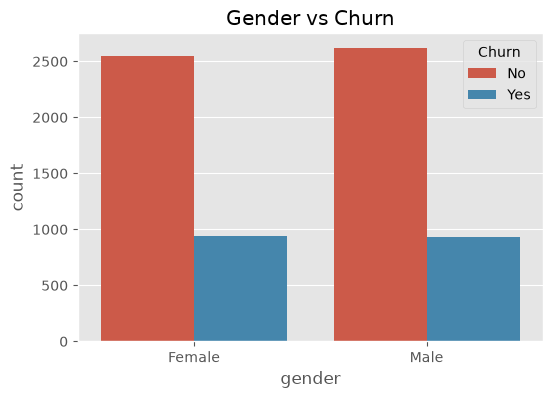

In [191]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Churn")

plt.show()

## Gender vs Churn

- Male and Female customers show similar churn behavior.
- Gender does not appear to strongly influence churn.

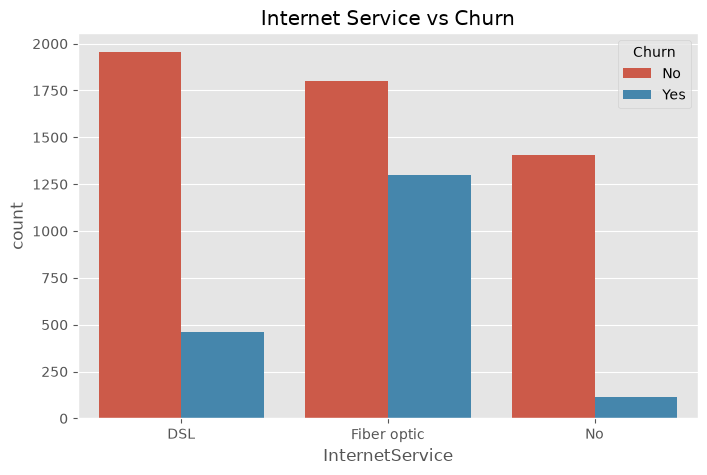

In [192]:
plt.figure(figsize=(8,5))

sns.countplot(x="InternetService",
              hue="Churn",
              data=df)

plt.title("Internet Service vs Churn")

plt.show()

## Internet Service vs Churn

- Fiber optic customers have a higher churn rate.
- Customers without internet service rarely churn.

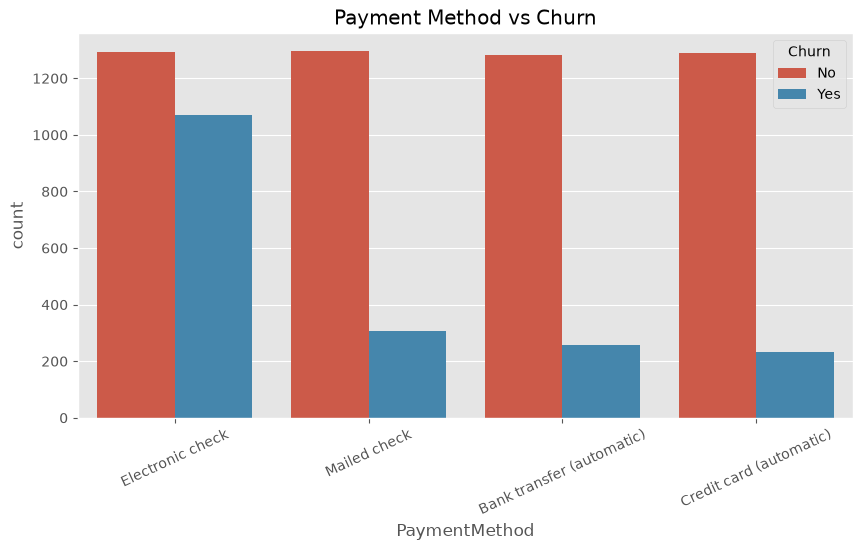

In [193]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=25)

plt.title("Payment Method vs Churn")

plt.show()

## Payment Method vs Churn

- Electronic check users show relatively higher churn.
- Other payment methods have lower churn.

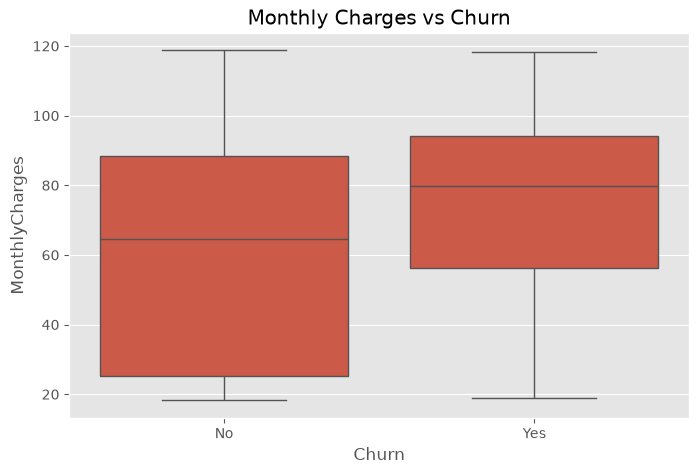

In [194]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

## Monthly Charges vs Churn

- Customers paying higher monthly charges tend to churn more.

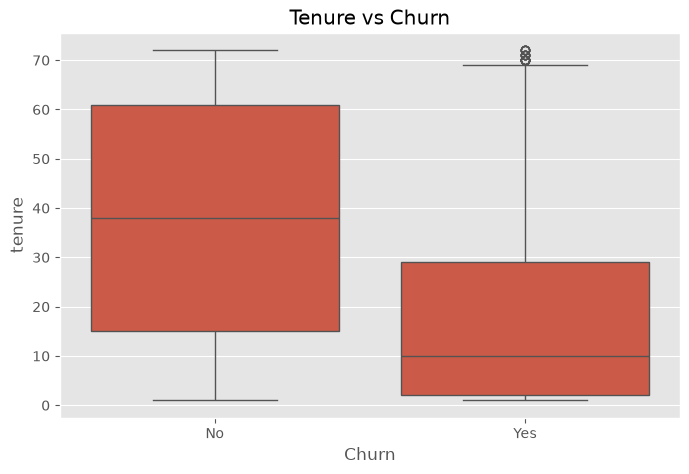

In [195]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

## Tenure vs Churn

- Customers with short tenure are more likely to churn.
- Long-term customers generally remain with the company.

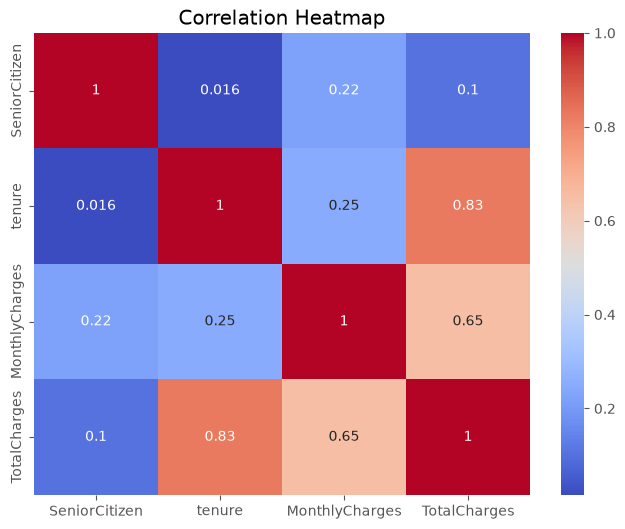

In [196]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Analysis

- TotalCharges and tenure have a strong positive correlation.
- MonthlyCharges and TotalCharges also show a positive correlation.
- No strong negative correlations are observed.

# Final EDA Insights

1. Most customers do not churn.
2. The dataset is slightly imbalanced.
3. Month-to-month contract customers churn the most.
4. Customers with longer tenure are less likely to churn.
5. Higher monthly charges are associated with higher churn.
6. Fiber optic customers show relatively higher churn.
7. Gender has little effect on churn.
8. TotalCharges is strongly correlated with tenure.